# Metaheuristic XAI Feature Selection — Benchmark

One notebook, four sections, run top to bottom:

1. **Setup** — paths, imports, registries
2. **Run the benchmark** — one config → smoke matrix → full `run_full_benchmark`
3. **Sensitivity** — alpha and hyper-parameter sweeps
4. **Analysis** — summary tables and plots

Everything writes under `<repo>/results` and `<repo>/plots` (`RESULTS_DIR`,
`PLOTS_DIR` below), independent of where Jupyter was launched. The full benchmark
cell is resumable — stop and re-run it freely.

## 1 · Setup

In [1]:
from pathlib import Path

import pandas as pd

import metaheuristic_xai
from metaheuristic_xai.classifiers import CLASSIFIER_REGISTRY
from metaheuristic_xai.complexity import get_complexity_summary
from metaheuristic_xai.config import (
    BENCHMARK_CONFIG,
    DEFAULT_METHOD_KWARGS,
    BenchmarkConfig,
    estimate_benchmark_budget,
    print_budget_report,
)
from metaheuristic_xai.datasets import list_datasets, load_dataset
from metaheuristic_xai.evaluation import (
    build_descriptive_summary,
    feature_stability,
    prepare_statistical_summary,
    save_results,
)
from metaheuristic_xai.plots import plot_metric_bars
from metaheuristic_xai.runner import (
    run_alpha_sensitivity,
    run_expanded_sensitivity,
    run_feature_selection,
    run_full_benchmark,
    run_hyperparameter_sensitivity,
)
from metaheuristic_xai.selectors import SELECTOR_REGISTRY

REPO_ROOT = Path(metaheuristic_xai.__file__).resolve().parents[2]
RESULTS_DIR = REPO_ROOT / "results"
PLOTS_DIR = REPO_ROOT / "plots"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print("results ->", RESULTS_DIR)

/Users/metasebiya21/personal_project/metaheuristic_xai_feature/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


results -> /Users/metasebiya21/personal_project/metaheuristic_xai_feature/results


In [2]:
print("Datasets:")
for d in list_datasets():
    print(f"  - {d['name']:<11} {d['scale_tier']:<10} {d['source']}")
print("\nClassifiers:", sorted(CLASSIFIER_REGISTRY))
print("Selectors  :", sorted(SELECTOR_REGISTRY))
print()
print(BENCHMARK_CONFIG)

Datasets:
  - wdbc        low        scikit-learn / UCI Wisconsin Diagnostic Breast Cancer
  - ionosphere  low        OpenML / UCI
  - madelon     medium     OpenML / NIPS 2003
  - colon       ultrahigh  OpenML / Alon et al.
  - leukemia    ultrahigh  OpenML / Golub et al.

Classifiers: ['lightgbm', 'mlp', 'random_forest', 'svm', 'xgboost']
Selectors  : ['boruta', 'bpso', 'ga', 'gwo', 'lasso', 'lime', 'nsga2', 'rfe', 'sa', 'shap']

BenchmarkConfig(datasets=['wdbc', 'ionosphere', 'madelon', 'colon', 'leukemia'], classifiers=['random_forest', 'xgboost', 'lightgbm', 'svm', 'mlp'], methods=['ga', 'bpso', 'sa', 'gwo', 'nsga2', 'shap', 'lime', 'lasso', 'rfe', 'boruta', 'full_features'], seeds=[42, 43, 44], method_kwargs={'ga': {'population_size': 50, 'generations': 40}, 'bpso': {'swarm_size': 50, 'iters': 40}, 'sa': {'initial_temp': 100.0, 'cooling': 0.95, 'max_steps': 2000}, 'gwo': {'population_size': 50, 'iterations': 40}, 'nsga2': {'population_size': 50, 'generations': 40}, 'shap': {'top_

In [3]:
print(get_complexity_summary())

 ASYMPTOTIC COMPUTATIONAL COMPLEXITY OF ALGORITHMS
 SHAP Top-k (shap):
   Time Complexity : O(C_model(D, N) + N_sub * D * M * depth)
   Space Complexity: O(N_sub * D + D)
   Evaluations     : E = 1
   Details         : Trains base model once; computes TreeExplainer SHAP values on N_sub samples.
------------------------------------------------------------------------------
 LIME Top-k (lime):
   Time Complexity : O(C_model(D, N) + N_sub * K_samples * C_model(D, 1))
   Space Complexity: O(N_sub * D)
   Evaluations     : E = 1
   Details         : Trains base model once; generates surrogate perturbations around N_sub samples.
------------------------------------------------------------------------------
 LASSO (L1 Logistic Regression) (lasso):
   Time Complexity : O(N * D^2 + D^3)
   Space Complexity: O(N * D + D)
   Evaluations     : E = 1
   Details         : Solves L1-regularized convex optimization problem using SAGA/coordinate descent.
------------------------------------------------

## 2 · Run the benchmark

### 2a. One configuration
A single (dataset, classifier, method, seed) evaluation.

In [4]:
bundle = load_dataset("wdbc", random_state=42)
record = run_feature_selection(
    bundle,
    classifier_name="random_forest",
    method_name="ga",
    seed=42,
    alpha=0.8,
    method_kwargs=DEFAULT_METHOD_KWARGS["ga"],
    defaults=DEFAULT_METHOD_KWARGS,
)
{k: record[k] for k in ("dataset", "method", "accuracy", "selected_features", "fitness", "actual_oracle_evaluations")}

2026-09-10 19:06:21,712 - metaheuristic_xai.datasets - INFO - Loading dataset 'wdbc' [low]


2026-09-10 19:06:21,718 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:06:21,718 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:06:21,736 - metaheuristic_xai.datasets - INFO - Dataset 'wdbc': raw D=30, preprocessed D=30, wrapper D=30, train=455, test=114


{'dataset': 'wdbc',
 'method': 'ga',
 'accuracy': 0.956140350877193,
 'selected_features': 6,
 'fitness': 0.07508771929824562,
 'actual_oracle_evaluations': 1759}

### 2b. Smoke matrix
A few seconds — confirms the pipeline end to end.

In [5]:
smoke_cfg = BenchmarkConfig(
    datasets=["wdbc"],
    classifiers=["random_forest"],
    methods=["ga", "shap", "full_features"],
    seeds=[42],
    method_kwargs=DEFAULT_METHOD_KWARGS,
)
smoke_df = run_full_benchmark(smoke_cfg, results_dir=RESULTS_DIR / "smoke", resume=False)
smoke_df[["dataset", "classifier", "method", "accuracy", "feature_ratio", "runtime_seconds"]]

2026-09-10 19:06:55,107 - metaheuristic_xai.datasets - INFO - Loading dataset 'wdbc' [low]


2026-09-10 19:06:55,112 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:06:55,112 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:06:55,118 - metaheuristic_xai.datasets - INFO - Dataset 'wdbc': raw D=30, preprocessed D=30, wrapper D=30, train=455, test=114


,dataset,classifier,method,accuracy,feature_ratio,runtime_seconds
0,wdbc,random_forest,ga,0.956140,0.200000,32.542056
1,wdbc,random_forest,shap,0.947368,0.333333,0.102425
2,wdbc,random_forest,full_features,0.956140,1.000000,0.000000


### 2c. Full benchmark

`bench_cfg` below is the full matrix: every dataset, every method, all five
classifiers, 3 seeds. `print_budget_report` shows the cost first.

**On a laptop (no usable GPU for these models):**
- `n_jobs=-1` fans the run out across CPU cores by (dataset, seed) group.
- swap `DEFAULT_METHOD_KWARGS` for `FAST_METHOD_KWARGS` (~4x fewer search
  evaluations) while iterating.
- `svm` and `mlp` are the slow classifiers; drop them from `classifiers` for a
  first pass.
- `resume=True` reuses per-run `.parquet` in `RESULTS_DIR`, so you can run one
  classifier (or dataset) at a time and re-run this cell to accumulate.

`save_results` writes `all_runs.csv` + `summary.csv` for section 4.

In [6]:
from metaheuristic_xai.config import FAST_METHOD_KWARGS  # or keep DEFAULT_METHOD_KWARGS

bench_cfg = BenchmarkConfig(
    datasets=BENCHMARK_CONFIG.datasets,        # wdbc, ionosphere, madelon, colon, leukemia
    classifiers=BENCHMARK_CONFIG.classifiers,  # random_forest, xgboost, lightgbm, svm, mlp
    methods=BENCHMARK_CONFIG.methods,          # all 10 selectors + full_features
    seeds=[42, 43, 44],
    method_kwargs=FAST_METHOD_KWARGS,
)

print_budget_report(
    estimate_benchmark_budget(
        bench_cfg.datasets, bench_cfg.classifiers, bench_cfg.methods,
        bench_cfg.seeds, bench_cfg.method_kwargs,
    )
)

 EXPERIMENTAL COMPUTATIONAL BUDGET ESTIMATION (DRY-RUN)
 Datasets   : 5
 Classifiers: 5
 Methods    : 11
 Seeds      : 3
 Total experiment runs      : 825
 Total classifier evaluations: 187,950
------------------------------------------------------------------------------
 Evaluations per method (single run):
   - ga          : 500
   - bpso        : 500
   - sa          : 500
   - gwo         : 500
   - nsga2       : 500
   - shap        : 1
   - lime        : 1
   - lasso       : 1
   - rfe         : 1
   - boruta      : 1
   - full_features: 1


In [7]:
df = run_full_benchmark(bench_cfg, results_dir=RESULTS_DIR, resume=True, n_jobs=-1)
save_results(df, RESULTS_DIR)
print(df.shape)
df[["dataset", "classifier", "method", "accuracy", "selected_features", "fitness"]].head(15)

2026-09-10 19:07:31,036 - metaheuristic_xai.evaluation - INFO - Saved raw and aggregated results to /Users/metasebiya21/personal_project/metaheuristic_xai_feature/results


(825, 34)


,dataset,classifier,method,accuracy,selected_features,fitness
0,colon,lightgbm,boruta,0.933333,78,0.105333
1,colon,lightgbm,boruta,0.933333,83,0.108667
2,colon,lightgbm,boruta,1.000000,83,0.055333
3,colon,lightgbm,bpso,0.933333,130,0.140000
4,colon,lightgbm,bpso,0.866667,134,0.196000
5,colon,lightgbm,bpso,0.933333,126,0.137333
6,colon,lightgbm,full_features,0.933333,300,0.253333
7,colon,lightgbm,full_features,0.933333,300,0.253333
8,colon,lightgbm,full_features,1.000000,300,0.200000
9,colon,lightgbm,ga,0.933333,90,0.113333


## 3 · Sensitivity sweeps

Optional. How selection behaviour moves with the fitness weight `alpha` and with
search hyper-parameters.

In [8]:
alpha_df = run_alpha_sensitivity(
    dataset_names=["wdbc", "ionosphere"],
    alpha_values=[0.5, 0.8],
    method_name="ga",
    classifier_name="random_forest",
    seeds=[0, 1],
    results_dir=RESULTS_DIR / "alpha_sensitivity",
)
alpha_df[["dataset", "method", "seed", "alpha", "accuracy", "feature_ratio"]].head()

2026-09-10 19:07:31,044 - metaheuristic_xai.datasets - INFO - Loading dataset 'wdbc' [low]


2026-09-10 19:07:31,048 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:07:31,048 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:07:31,054 - metaheuristic_xai.datasets - INFO - Dataset 'wdbc': raw D=30, preprocessed D=30, wrapper D=30, train=455, test=114


2026-09-10 19:09:04,436 - metaheuristic_xai.datasets - INFO - Loading dataset 'wdbc' [low]


...

2026-09-10 19:12:12,131 - metaheuristic_xai.datasets - INFO - Loaded 'ionosphere' from OpenML: N=351, D=34


2026-09-10 19:12:12,132 - metaheuristic_xai.datasets - INFO - Validated dataset 'ionosphere': N=351, D=34, classes=2


2026-09-10 19:12:12,132 - metaheuristic_xai.datasets - INFO - Validated dataset 'ionosphere': N=351, D=34, classes=2


2026-09-10 19:12:12,137 - metaheuristic_xai.datasets - INFO - Dataset 'ionosphere': raw D=34, preprocessed D=33, wrapper D=33, train=280, test=71


,dataset,method,seed,alpha,accuracy,feature_ratio
0,wdbc,ga,0,0.5,0.956140,0.100000
1,wdbc,ga,0,0.8,0.938596,0.133333
2,wdbc,ga,1,0.5,0.929825,0.066667
3,wdbc,ga,1,0.8,0.956140,0.166667
4,ionosphere,ga,0,0.5,0.873239,0.090909


In [9]:
param_df = run_hyperparameter_sensitivity(
    "ga",
    dataset_name="wdbc",
    classifier_name="random_forest",
    seeds=[42],
    param_grid={"population_size": [10, 20], "generations": [5, 10]},
    alpha_values=[0.5, 0.8],
    results_dir=RESULTS_DIR / "sensitivity",
)
param_df[["dataset", "method", "seed", "alpha", "method_kwargs", "accuracy"]].head()

2026-09-10 19:13:57,335 - metaheuristic_xai.datasets - INFO - Loading dataset 'wdbc' [low]


2026-09-10 19:13:57,340 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:13:57,340 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:13:57,346 - metaheuristic_xai.datasets - INFO - Dataset 'wdbc': raw D=30, preprocessed D=30, wrapper D=30, train=455, test=114


2026-09-10 19:13:59,818 - metaheuristic_xai.datasets - INFO - Loading dataset 'wdbc' [low]


...

2026-09-10 19:14:23,151 - metaheuristic_xai.datasets - INFO - Loading dataset 'wdbc' [low]


2026-09-10 19:14:23,154 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:14:23,154 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:14:23,160 - metaheuristic_xai.datasets - INFO - Dataset 'wdbc': raw D=30, preprocessed D=30, wrapper D=30, train=455, test=114


,dataset,method,seed,alpha,method_kwargs,accuracy
0,wdbc,ga,42,0.5,"{'population_size': 10, 'generations': 5}",0.947368
1,wdbc,ga,42,0.8,"{'population_size': 10, 'generations': 5}",0.947368
2,wdbc,ga,42,0.5,"{'population_size': 10, 'generations': 10}",0.956140
3,wdbc,ga,42,0.8,"{'population_size': 10, 'generations': 10}",0.956140
4,wdbc,ga,42,0.5,"{'population_size': 20, 'generations': 5}",0.938596


In [10]:
expanded_df = run_expanded_sensitivity(
    dataset_name="wdbc",
    classifier_name="random_forest",
    method_name="ga",
    alpha_values=[0.3, 0.5, 0.8],
    seeds=[42, 43],
    results_dir=RESULTS_DIR / "expanded_sensitivity",
)
expanded_df[["dataset", "method", "seed", "alpha", "accuracy", "feature_ratio"]].head()

2026-09-10 19:14:28,455 - metaheuristic_xai.datasets - INFO - Loading dataset 'wdbc' [low]


2026-09-10 19:14:28,458 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:14:28,459 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:14:28,465 - metaheuristic_xai.datasets - INFO - Dataset 'wdbc': raw D=30, preprocessed D=30, wrapper D=30, train=455, test=114


2026-09-10 19:14:35,516 - metaheuristic_xai.datasets - INFO - Loading dataset 'wdbc' [low]


...

2026-09-10 19:25:55,289 - metaheuristic_xai.datasets - INFO - Loading dataset 'wdbc' [low]


2026-09-10 19:25:55,292 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:25:55,292 - metaheuristic_xai.datasets - INFO - Validated dataset 'wdbc': N=569, D=30, classes=2


2026-09-10 19:25:55,298 - metaheuristic_xai.datasets - INFO - Dataset 'wdbc': raw D=30, preprocessed D=30, wrapper D=30, train=455, test=114


,dataset,method,seed,alpha,accuracy,feature_ratio
0,wdbc,ga,42,0.3,0.894737,0.100000
1,wdbc,ga,43,0.3,0.894737,0.133333
2,wdbc,ga,42,0.5,0.903509,0.066667
3,wdbc,ga,43,0.5,0.894737,0.166667
4,wdbc,ga,42,0.8,0.938596,0.166667


## 4 · Analysis (leakage-controlled)

Loads `all_runs.csv` from section 2c. `accuracy` is **held-out test** accuracy;
`val_accuracy` is the inner-validation score the search optimised;
`generalization_gap = val_accuracy - accuracy` measures search overfitting.
All figures are written to `PLOTS_DIR`.

In [11]:
from metaheuristic_xai.runner import load_results

# reads every per-run parquet in RESULTS_DIR (works before the final
# save_results writes all_runs.csv, and across multi-pass runs)
results_df = load_results(RESULTS_DIR)

import importlib
import metaheuristic_xai.evaluation as evaluation

evaluation = importlib.reload(evaluation)
from metaheuristic_xai.evaluation import (
    method_summary,
    per_dataset_metric,
    generalization_gap_by_tier,
    friedman_nemenyi,
    holm_wilcoxon_vs,
    feature_stability,
)
from metaheuristic_xai.plots import (
    plot_accuracy_parsimony,
    plot_generalization_gap_bars,
    plot_stability_bars,
    plot_cd_diagram,
    display_saved_image,
)
print(results_df.shape, "runs")
results_df[["dataset", "classifier", "method", "seed"]].nunique()

(825, 34) runs


dataset        5
classifier     5
method        11
seed           3
dtype: int64

### 4a · Per-method summary  (mean over datasets x classifiers x seeds)

In [12]:
method_summary(results_df)

,family,n,test_acc,test_acc_sd,balanced_acc,f1,roc_auc,val_acc,gen_gap,n_features,feature_ratio,fitness,runtime_s,oracle_evals
method,,,,,,,,,,,,,,
ga,scalar_metaheuristic,75,0.8648,0.1152,0.8493,0.8441,0.9231,0.9284,0.0637,89.8133,0.3292,0.1740,104.5191,437.8667
bpso,scalar_metaheuristic,75,0.8708,0.1148,0.8583,0.8564,0.9213,0.9191,0.0484,105.9200,0.3855,0.1805,229.2159,502.0000
sa,scalar_metaheuristic,75,0.8634,0.1261,0.8477,0.8444,0.9124,0.9202,0.0568,96.5600,0.3448,0.1782,193.9187,503.0000
gwo,scalar_metaheuristic,75,0.8745,0.1172,0.8590,0.8563,0.9165,0.9227,0.0482,99.8133,0.3674,0.1739,225.3785,526.0000
nsga2,multiobjective,75,0.8637,0.1184,0.8503,0.8491,0.9105,0.9296,0.0658,83.0133,0.2793,0.1649,210.5821,526.0000
shap,xai,75,0.8919,0.0819,0.8753,0.8626,0.9444,0.8939,0.0020,10.0000,0.1446,0.1154,1.4905,1.0000
lime,xai,75,0.8963,0.0756,0.8779,0.8615,0.9407,0.8901,-0.0061,10.0000,0.1446,0.1119,52.0370,1.0000
lasso,classical,75,0.8523,0.1470,0.8407,0.8378,0.8990,0.8658,0.0135,121.2667,0.5839,0.2349,25.1973,1.0000
rfe,classical,75,0.8995,0.0742,0.8834,0.8698,0.9410,0.8985,-0.0010,10.0000,0.1446,0.1093,5.9435,1.0000


### 4b · Per-dataset breakdown  (generalizability)

In [13]:
per_dataset_metric(results_df, "accuracy")

dataset,colon,ionosphere,leukemia,madelon,wdbc
method,,,,,
ga,0.9022,0.8967,0.8756,0.7055,0.9439
bpso,0.9067,0.8986,0.8933,0.7109,0.9444
sa,0.9200,0.8930,0.8844,0.6660,0.9538
gwo,0.9200,0.9033,0.8978,0.7094,0.9421
nsga2,0.9067,0.8826,0.8711,0.7103,0.9480
shap,0.9244,0.9061,0.8400,0.8446,0.9444
lime,0.9289,0.9023,0.8489,0.8410,0.9602
lasso,0.9111,0.9164,0.9022,0.5799,0.9520
rfe,0.9333,0.9061,0.8444,0.8515,0.9620


In [14]:
per_dataset_metric(results_df, "selected_features")

dataset,colon,ionosphere,leukemia,madelon,wdbc
method,,,,,
ga,99.8000,9.7333,105.7333,227.4667,6.3333
bpso,130.6667,9.2667,131.0000,250.4667,8.2000
sa,110.0000,9.7333,112.6000,244.5333,5.9333
gwo,124.1333,9.4667,122.3333,235.4000,7.7333
nsga2,95.2667,6.0667,98.7333,210.6667,4.3333
shap,10.0000,10.0000,10.0000,10.0000,10.0000
lime,10.0000,10.0000,10.0000,10.0000,10.0000
lasso,196.3333,22.3333,210.3333,160.3333,17.0000
rfe,10.0000,10.0000,10.0000,10.0000,10.0000


### 4c · Statistical comparison  (Demsar protocol)

Friedman omnibus across all methods on test accuracy, then the Nemenyi
critical-difference post-hoc. Methods joined by a bar are **not** significantly
different.

In [1]:
fn = friedman_nemenyi(results_df, "accuracy")
print(f"Friedman chi2 = {fn.statistic:.1f}   p = {fn.pvalue:.2e}   "
      f"(n_subjects = {fn.n_subjects}, k = {fn.n_methods}, CD = {fn.cd:.2f})")
plot_cd_diagram(fn.mean_ranks, fn.cd, PLOTS_DIR / "cd_diagram.png")
display_saved_image(PLOTS_DIR / "cd_diagram.png", figsize=(10, 6))
fn.mean_ranks.to_frame("mean_rank")

NameError: name 'friedman_nemenyi' is not defined

Paired Wilcoxon signed-rank of every method vs SHAP, Holm-corrected, with matched-pairs rank-biserial effect size.

In [16]:
holm_wilcoxon_vs(results_df, baseline="shap", metric="accuracy")

,method,n_pairs,mean_accuracy_diff,win_rate,rank_biserial,p_raw,p_holm
0,boruta,75,0.0272,0.600,0.690,0.0000,0.0001
1,rfe,75,0.0076,0.413,0.312,0.0573,0.3778
2,lime,75,0.0044,0.293,-0.029,0.8713,1.0000
3,full_features,75,-0.0107,0.360,-0.066,0.6869,1.0000
4,gwo,75,-0.0174,0.307,-0.221,0.1357,0.4349
5,bpso,75,-0.0211,0.307,-0.246,0.1087,0.4349
6,ga,75,-0.0271,0.267,-0.388,0.0115,0.0920
7,nsga2,75,-0.0282,0.253,-0.440,0.0038,0.0343
8,sa,75,-0.0285,0.293,-0.295,0.0546,0.3778
9,lasso,75,-0.0396,0.293,-0.307,0.0540,0.3778


### 4d · Search overfitting  (validation - test accuracy, by dimensionality tier)

scale_tier,low,medium,ultrahigh
method,,,
ga,0.0390,0.0314,0.1044
bpso,0.0259,0.0122,0.0889
sa,0.0324,0.0414,0.0889
gwo,0.0309,0.0237,0.0778
nsga2,0.0435,0.0288,0.1067
shap,-0.0134,-0.0167,0.0267
lime,-0.0111,-0.0306,0.0111
lasso,-0.0137,0.0504,0.0222
rfe,-0.0159,-0.0309,0.0289


2026-09-10 19:26:27,678 - metaheuristic_xai.plots - INFO - Saved generalization-gap plot: /Users/metasebiya21/personal_project/metaheuristic_xai_feature/plots/generalization_gap.png


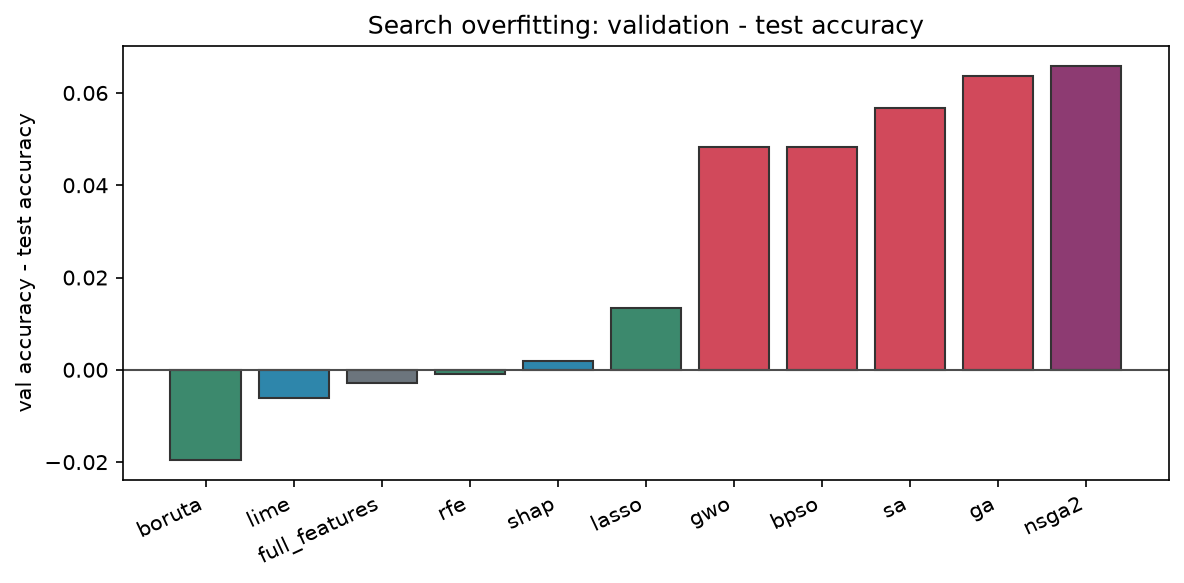

In [17]:
display(generalization_gap_by_tier(results_df))
plot_generalization_gap_bars(results_df, PLOTS_DIR / "generalization_gap.png")
display_saved_image(PLOTS_DIR / "generalization_gap.png", figsize=(9, 4))

### 4e · Selection stability across seeds  (1 = identical subset, ~0 = random)

,mean_jaccard,nogueira_stability,mean_selected
method,,,
boruta,0.656,0.408,47.533
bpso,0.252,0.015,105.920
full_features,1.000,1.000,232.600
ga,0.205,0.003,89.813
gwo,0.240,0.019,99.813
lasso,0.537,0.228,121.267
lime,0.408,0.449,10.000
nsga2,0.184,0.027,83.013
rfe,0.453,0.469,10.000


2026-09-10 19:26:27,849 - metaheuristic_xai.plots - INFO - Saved stability plot: /Users/metasebiya21/personal_project/metaheuristic_xai_feature/plots/stability.png


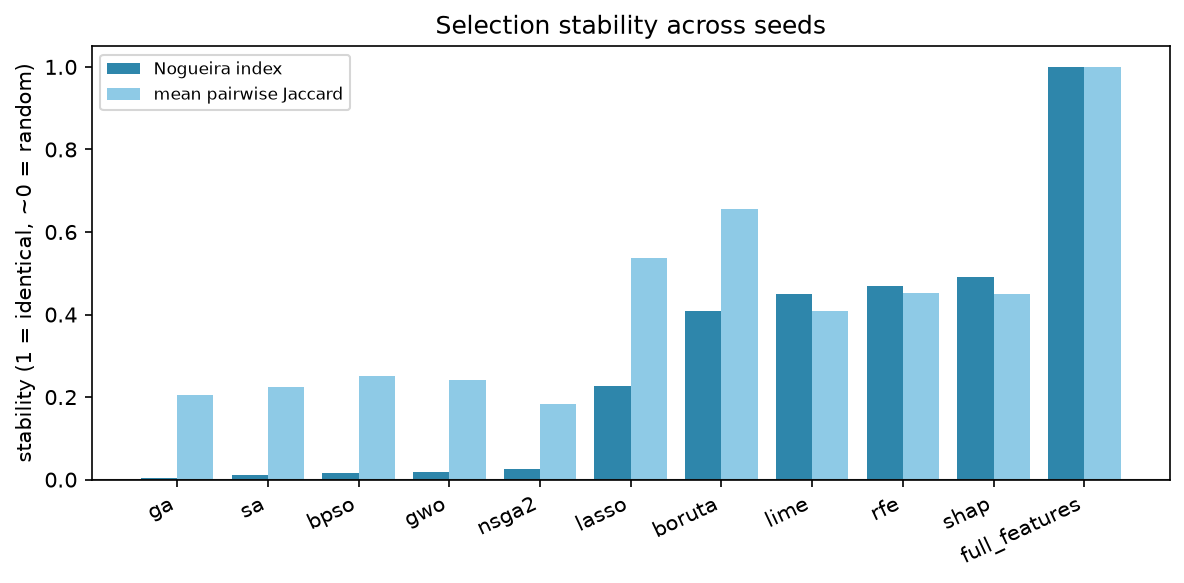

In [18]:
stab = feature_stability(results_df).groupby("method")[["mean_jaccard", "nogueira_stability", "mean_selected"]].mean()
display(stab.round(3))
plot_stability_bars(results_df, PLOTS_DIR / "stability.png")
display_saved_image(PLOTS_DIR / "stability.png", figsize=(9, 4))

### 4f · Accuracy vs. parsimony frontier

2026-09-10 19:26:28,062 - metaheuristic_xai.plots - INFO - Saved accuracy/parsimony plot: /Users/metasebiya21/personal_project/metaheuristic_xai_feature/plots/accuracy_parsimony.png


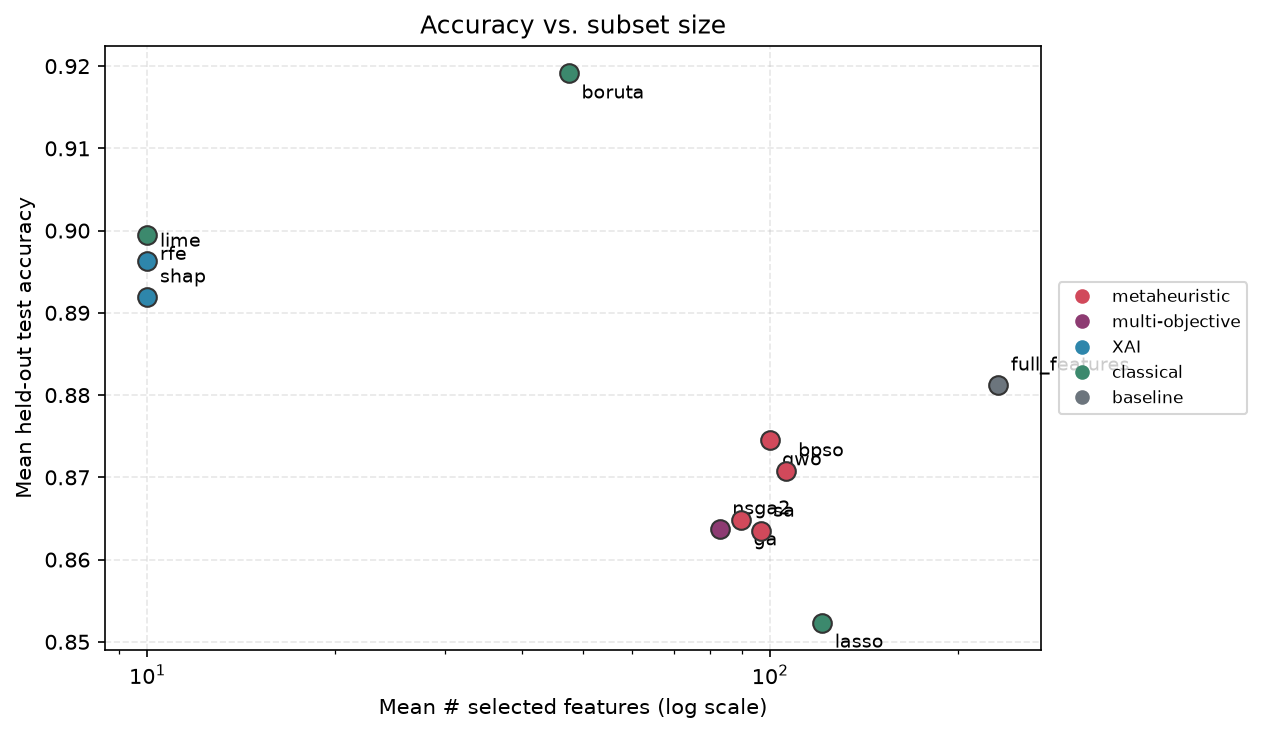

In [19]:
plot_accuracy_parsimony(results_df, PLOTS_DIR / "accuracy_parsimony.png")
display_saved_image(PLOTS_DIR / "accuracy_parsimony.png", figsize=(9, 5.5))

## 5 · Data-leakage verification

Reproduces the original wrapper evaluation, where the GA fitness was the accuracy
on the **held-out test set**, alongside the leakage-free version (search scored on
an inner validation split of the training partition). Tree-SHAP is identical in
both -- it never queries the oracle.

The full run is 5 datasets x 10 splits x (GA-on-test + GA-leakage-free + SHAP),
GA pop 50 / 50 generations, alpha = 0.9 -- ~2-3 h. The cell below **loads
`results/leakage_verification.csv` if it already exists**; delete that file (or
trim `seeds` / `ga_kwargs`) to recompute.

In [20]:
from metaheuristic_xai.runner import run_leakage_verification
from metaheuristic_xai.plots import plot_leakage_verification

leak_csv = RESULTS_DIR / "leakage_verification.csv"
if leak_csv.exists():
    leak_df = pd.read_csv(leak_csv)
    print(f"loaded {len(leak_df)} rows from {leak_csv.name}")
else:
    leak_df = run_leakage_verification(
        datasets=BENCHMARK_CONFIG.datasets,          # all 5 datasets
        seeds=list(range(42, 52)),                   # 10 stratified splits
        alpha=0.9,
        ga_kwargs={"population_size": 50, "generations": 50},
        n_jobs=-1,
        results_path=leak_csv,
    )
leak_df.groupby(["dataset", "method", "condition"])["test_accuracy"].mean().round(3).unstack("condition")

loaded 150 rows from leakage_verification.csv


condition             (no oracle)  leakage-free  original (search on test)
dataset    method                                                         
colon      GA                 NaN         0.967                      0.987
           Tree-SHAP        0.933           NaN                        NaN
ionosphere GA                 NaN         0.908                      0.980
           Tree-SHAP        0.921           NaN                        NaN
leukemia   GA                 NaN         0.973                      0.987
           Tree-SHAP        0.940           NaN                        NaN
madelon    GA                 NaN         0.759                      0.803
           Tree-SHAP        0.865           NaN                        NaN
wdbc       GA                 NaN         0.951                      0.985
           Tree-SHAP        0.947           NaN                        NaN

### 5a · GA leakage inflation, per dataset

In [21]:
ga = leak_df[leak_df.method == "GA"].pivot_table(
    index="dataset", columns="condition", values="test_accuracy", aggfunc="mean")
shap = leak_df[leak_df.method == "Tree-SHAP"].groupby("dataset")["test_accuracy"].mean()
orig = next(c for c in ga.columns if "test" in c)
free = next(c for c in ga.columns if "free" in c)

inflation = pd.DataFrame({
    "GA_original":       ga[orig].round(4),
    "GA_leakage_free":   ga[free].round(4),
    "inflation_points":  ((ga[orig] - ga[free]) * 100).round(2),
    "Tree_SHAP":         shap.round(4),
    "GAfree_minus_SHAP_points": ((ga[free] - shap) * 100).round(2),
})
inflation.loc["POOLED"] = [
    ga[orig].mean(), ga[free].mean(), (ga[orig].mean() - ga[free].mean()) * 100,
    shap.mean(), (ga[free].mean() - shap.mean()) * 100,
]
inflation.round(4)

,GA_original,GA_leakage_free,inflation_points,Tree_SHAP,GAfree_minus_SHAP_points
dataset,,,,,
colon,0.9867,0.9667,2.0000,0.9333,3.3300
ionosphere,0.9803,0.9085,7.1800,0.9211,-1.2700
leukemia,0.9867,0.9733,1.3300,0.9400,3.3300
madelon,0.8035,0.7587,4.4800,0.8646,-10.6000
wdbc,0.9851,0.9509,3.4200,0.9474,0.3500
POOLED,0.9484,0.9116,3.6837,0.9213,-0.9692


### 5b · Generalization gap under each condition

In [22]:
# GA 'original' has val == test by construction (same held-out set), so its
# generalization gap is exactly 0 -- an artifact of having no separate validation.
leak_df.groupby(["method", "condition"])[["val_accuracy", "test_accuracy", "generalization_gap", "n_features"]].mean().round(4)

val_accuracy  test_accuracy  \
method    condition                                                
GA        leakage-free                     0.9410         0.9116   
          original (search on test)        0.9484         0.9484   
Tree-SHAP (no oracle)                      0.9319         0.9213   

                                     generalization_gap  n_features  
method    condition                                                  
GA        leakage-free                           0.0294       77.94  
          original (search on test)              0.0000       78.36  
Tree-SHAP (no oracle)                            0.0107       10.00

### 5c · GA on test set vs held out vs Tree-SHAP

2026-09-10 19:26:28,176 - metaheuristic_xai.plots - INFO - Saved leakage-verification plot: /Users/metasebiya21/personal_project/metaheuristic_xai_feature/plots/leakage_verification.png


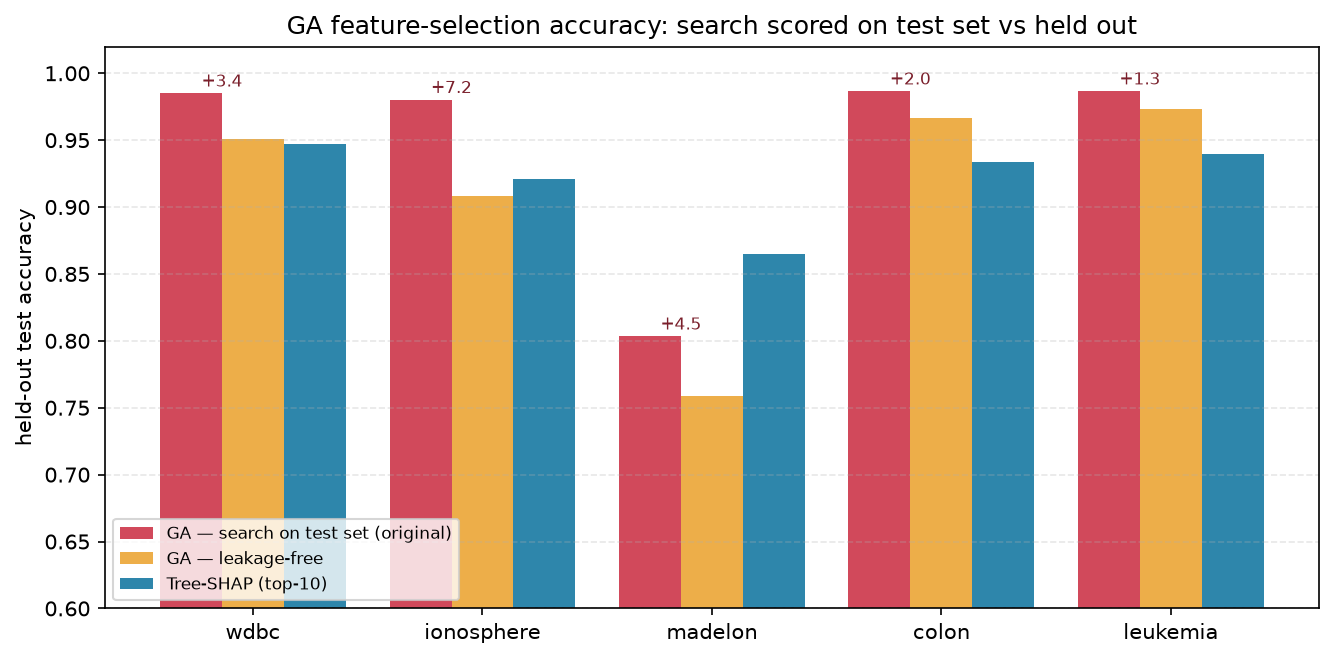

In [23]:
plot_leakage_verification(leak_df, PLOTS_DIR / "leakage_verification.png")
display_saved_image(PLOTS_DIR / "leakage_verification.png", figsize=(10, 5))